__Практика Docker__

__Основные команды__

1) docker version

Чтоб посмотреть версию Docker'a

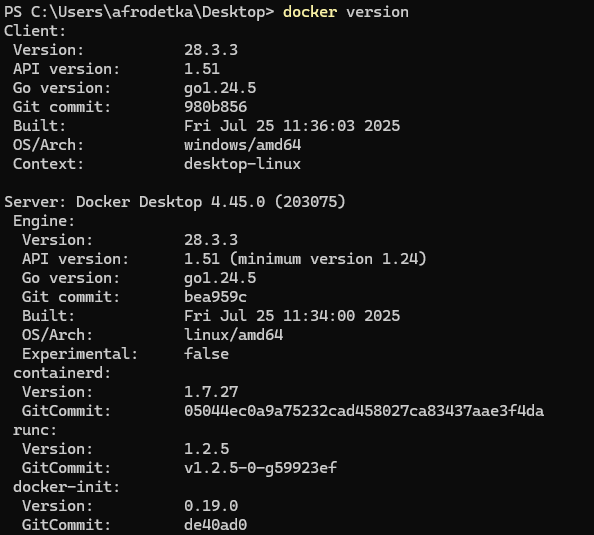

2) docker ps -a

Чтоб посмотреть список запущенных и остановленных контейнеров:

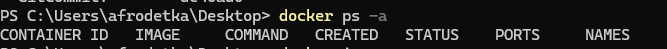

Без опции a только запущенные

3) docker images 

показывает список локальных образов

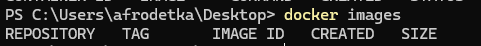

4) docker run < название образа >

создает и запускает контейнера из образа

Сначал ищет локально, потом обращается на DockerHub и качает его локально, затем создает контейнер

Также мы можем указывать тэги, чтоб скачивать конкретные версии образа

чтоб запускать контейнер в фоновом режиме используем флаг -d

флаг name позволяет задать имя

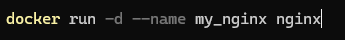

флаг rm дает возможность автоматического удаления контейнера после того как он стопнется

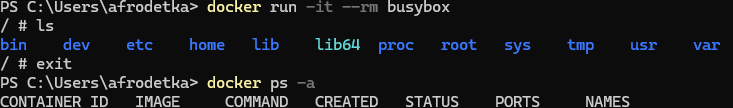

5) Чтоб только скачать образ с docker hub:

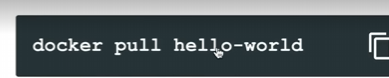

каждому контейнеру присваивается имя (его также можно установить вручную)

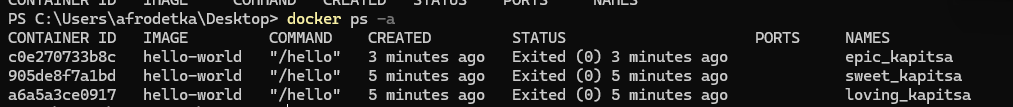

6) docker rm < id контейнера или имя > 

удалить контейнеры

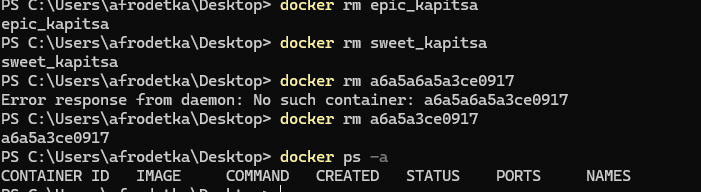

7) docker run -it < название контейнера >

подключиться к процессу контейнера

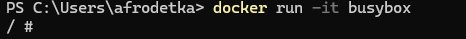\

внутри можно вводить разлиные команды, вот пример содержания контейнера

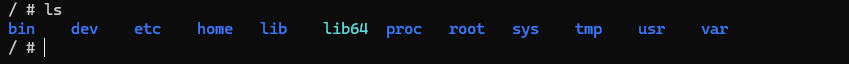

У каждого контейнера свой ip-адрес, чтоб его посмотреть используется команда:

hostname -i

ip-адрес присваивается автоматически

также может быть доступ к ресурсам в интернете, чтоб проверить этот доступ можно пингануть днс гугл ping 8.8.8.8

8) docker stop < айди контейнера > или docker kill

остановить работу контейнера

9) docker container prune

удалить все стопнутые контейнеры

10) docker inspect < docker id / docker name>

чтоб посмотреть детали определенного контейнера 

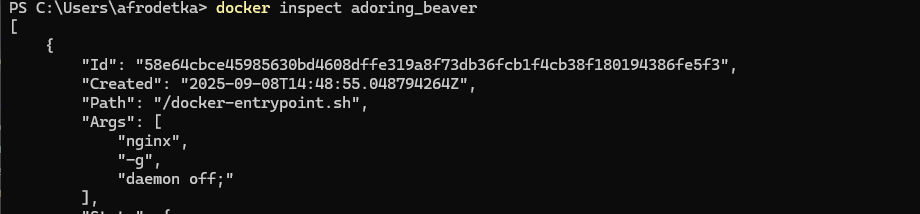

11) docker exec -it < id/имя контейнера > < название процесса >

Таким образом можно запустить любой процесс внутри контейнера, если контейнер запущен

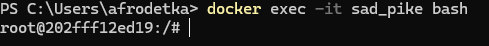

__Создание контейнера на основании образа NGINX__

С помощью NGINX можно быстро создать веб-сервер и передавать клиентам (веб-браузер, приложения) различные веб-файлы

Такой образ доступен на DockerHub

1) docker run nginx 

2) после создание контейнера терминал автоматически подключается к процессам контейнера

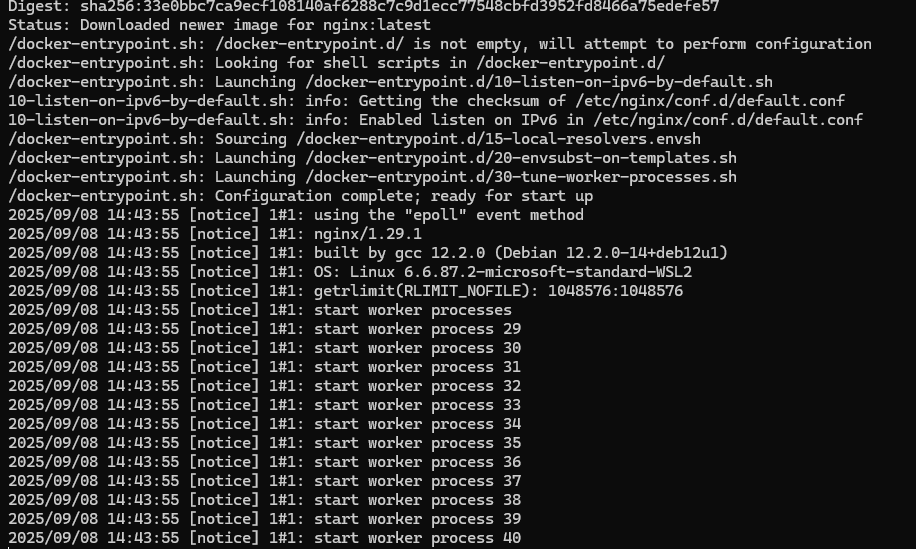

Можем после посмотреть количество активных контейнеров и увидеть порт 80/tcp

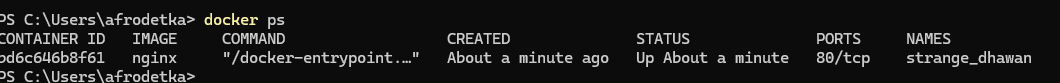

3) создадим его в фоновом режиме, используя docker run -d nginx

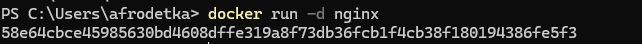

получим айди контейнера и увидим, что контейнер работает в фоновом режиме

4) откроем свой порт и пробросим его внутрь контейнера, используя мэппинг портов

docker run -p 8080:80 nginx

-p -> публикация порта

8080 -> внешний порт

80 -> порт контейнера

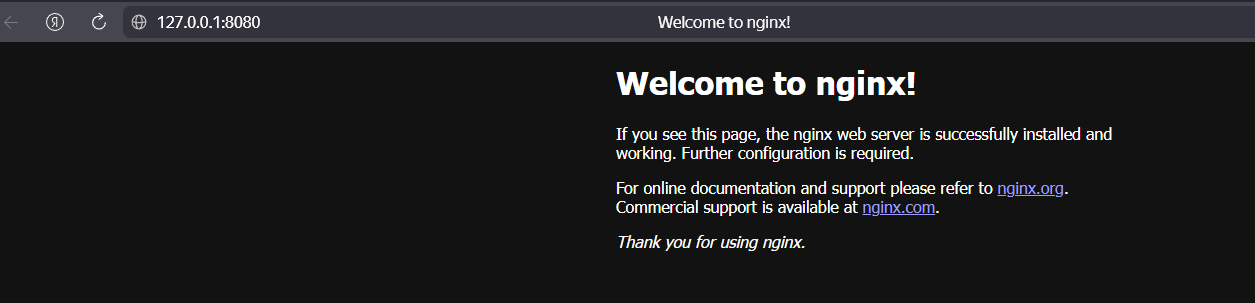

5) Мы можем заменить html страниц, используя мэппинг томов

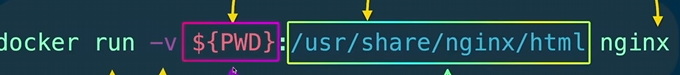

__Создание образов__


Этапы: 

1) Для создания образа необходимо создать Dockerfile

Dockerfile - специальный файл с инструкциями для Docker по созданию нового образа (один докерфайл для одного образа)

2) Обычно Dockerfile помещают в корне папки приложения

3) Dockerfile содержит инструкции по созданию образа

4) При создании образа можно указать имя и тег для образа

если не указать - докер установит их автоматиески

теги используются для разных версий

5) На основании готового образа можно создавать контейнеры

новый образ будет находиться локально на компьютере

при создании собственного образа нужно указывать базовый образ, который берется за основу

Пример Dockerfile:

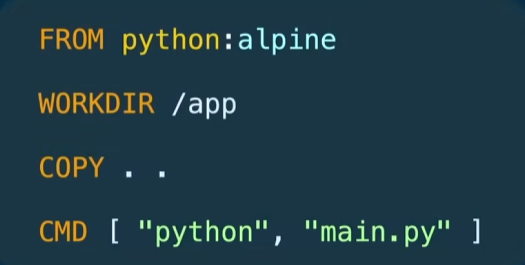

FROM python:alpine <- имя и тэг базового образа 

WORKDIR /app <- рабоая директория (рекомендуется всегда ее создавать для приложения)

COPY . . <- копируем все файлы из локальной текущей папки в папку воркдир внутри контейнера, то есть докер автоматически перейдт в папку /app

CMD [ "python", "main.py" ] <- команда, которая будет выполнена когда создастся контейенр на основании уже созданного образа (запускается процесс пайтон и ему передается main.py)

После того как мы сохраним Dockerfile можно использовать команду

docker build . (. <- Путь к Dockerfile), если название файлы не Dockerfile нужно указать опцию -f, 

чтобы добавить определенно имя нужно использовать опцию -t 

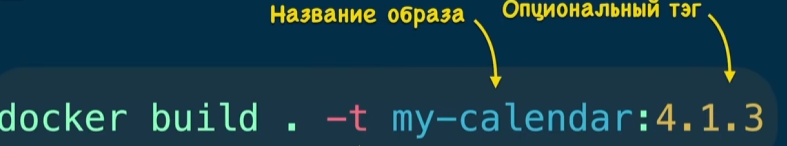

если тэг опустить, то докер добавит тэг latest

после докер пройдется по всем инструкциям и создаст новый образ

__Как запустить python прогу через Docker__

Вот у нас есть простая прога:

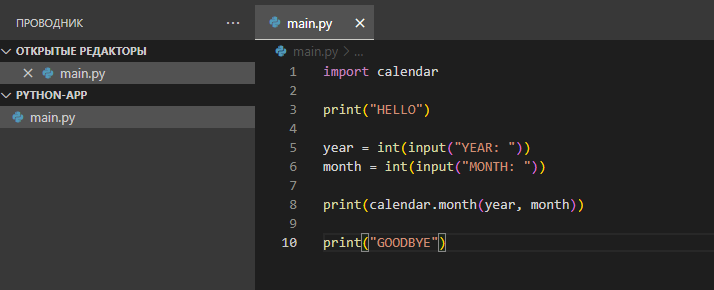

Чтоб ее запустить нужно:

1) Создать Dockerfile внутри папки

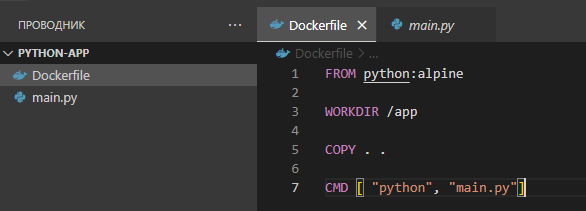

2) забилдить образ 

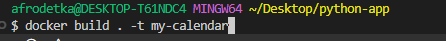

Вот наш образ:

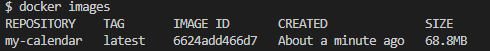

3) создадим контейнер

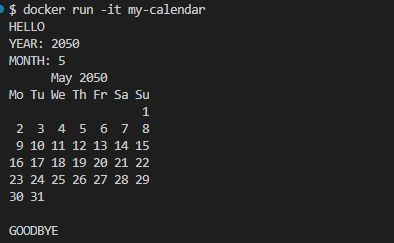
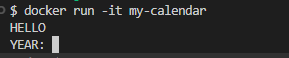

__Создание сервиса с помощью Docker Compose__

где один серсив мы билдим, используя докерфайл, а один импортируем с докерхаба

1) Создадим базовую структуру проекта

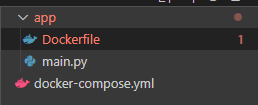

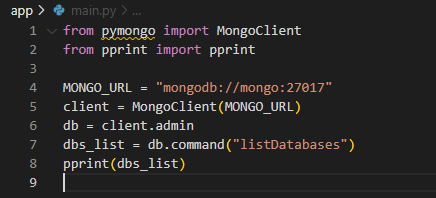

2) Сконфигурируем докерфайл

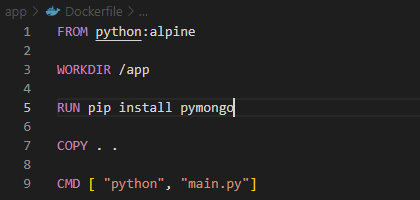

RUN нужен чтоб импортировать библиотеку pymongo

3) Создаем docker-compose.yml

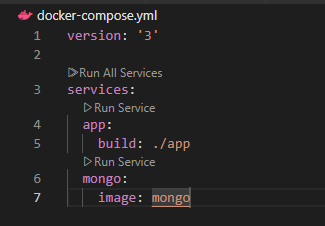

4) создаем

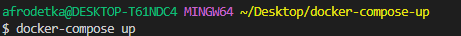

можно испльзовать флаг -d, чтоб запустить в фоновом режиме

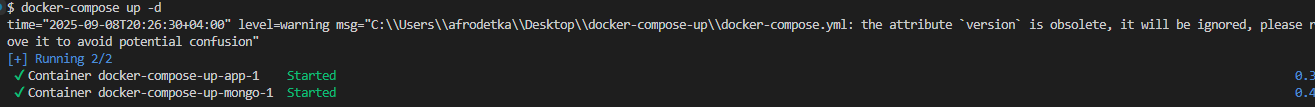

5) остановим все контейнеры и удалим их

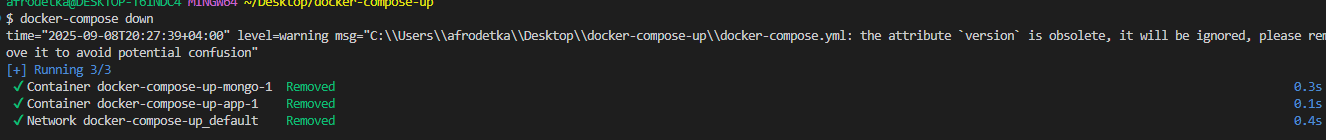

6) Чтоб создать образ заново:

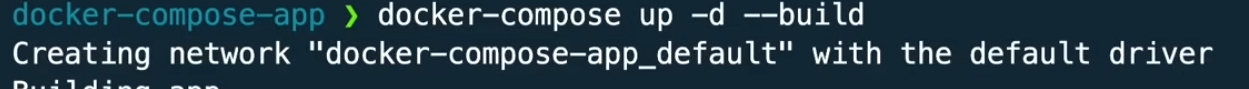